In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar el dataset
df = pd.read_csv('../datos/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Primera exploración
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
df.head()

Matplotlib is building the font cache; this may take a moment.


Dimensiones del dataset: (7043, 21)

Primeras 5 filas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Información general del dataset
print("=== INFORMACIÓN DEL DATASET ===")
print(df.info())

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTADÍSTICAS BÁSICAS ===")
df.describe()

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


=== DISTRIBUCIÓN DE CHURN ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


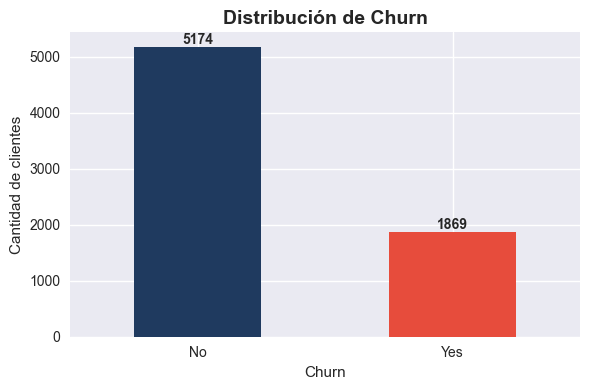

Gráfico guardado ✓


In [3]:
# Distribución de Churn
print("=== DISTRIBUCIÓN DE CHURN ===")
print(df['Churn'].value_counts())
print("\nPorcentaje:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

# Gráfico
plt.figure(figsize=(6, 4))
ax = df['Churn'].value_counts().plot(kind='bar', color=['#1F3A5F', '#E74C3C'])
plt.title('Distribución de Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../imagenes/01_distribucion_churn.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

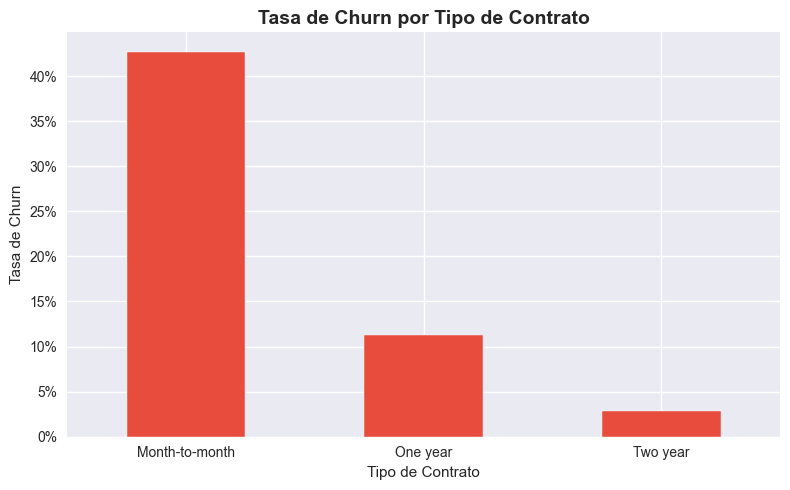


Tasa de churn por contrato:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Yes, dtype: float64


In [4]:
# Churn por tipo de contrato
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].sort_values(ascending=False).plot(
    kind='bar', color='#E74C3C', edgecolor='white')
plt.title('Tasa de Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Churn')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig('../imagenes/02_churn_por_contrato.png', dpi=150)
plt.show()

print("\nTasa de churn por contrato:")
print((contract_churn['Yes'] * 100).round(1))

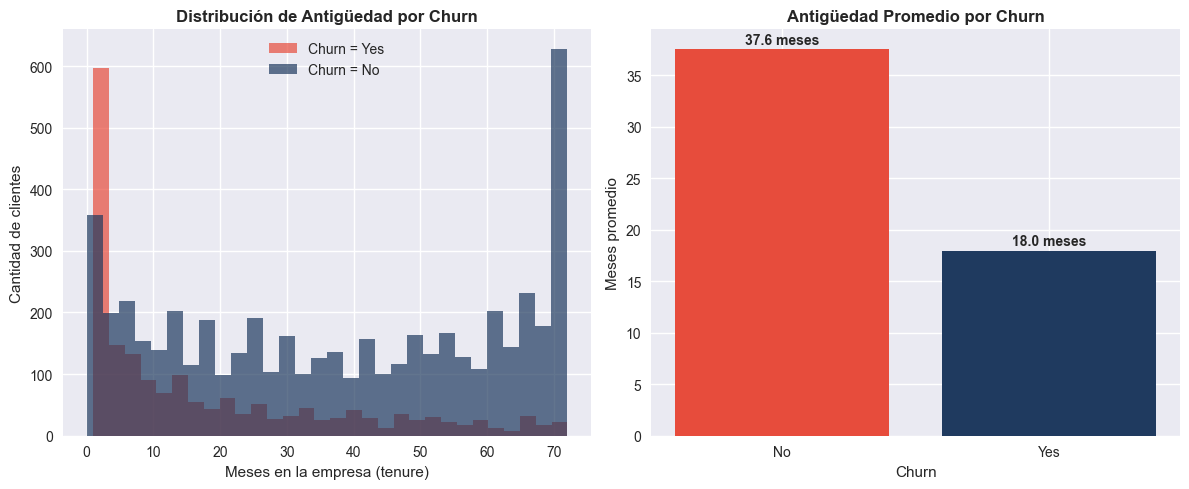


Antigüedad promedio:
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64


In [5]:
# Churn por antigüedad (tenure)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de tenure por churn
df[df['Churn'] == 'Yes']['tenure'].hist(
    bins=30, ax=axes[0], color='#E74C3C', alpha=0.7, label='Churn = Yes')
df[df['Churn'] == 'No']['tenure'].hist(
    bins=30, ax=axes[0], color='#1F3A5F', alpha=0.7, label='Churn = No')
axes[0].set_title('Distribución de Antigüedad por Churn', fontweight='bold')
axes[0].set_xlabel('Meses en la empresa (tenure)')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].legend()

# Promedio de tenure por churn
tenure_avg = df.groupby('Churn')['tenure'].mean()
axes[1].bar(tenure_avg.index, tenure_avg.values,
            color=['#E74C3C', '#1F3A5F'])
axes[1].set_title('Antigüedad Promedio por Churn', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Meses promedio')
for i, v in enumerate(tenure_avg.values):
    axes[1].text(i, v + 0.5, f'{v:.1f} meses', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../imagenes/03_churn_por_tenure.png', dpi=150)
plt.show()

print("\nAntigüedad promedio:")
print(tenure_avg.round(1))

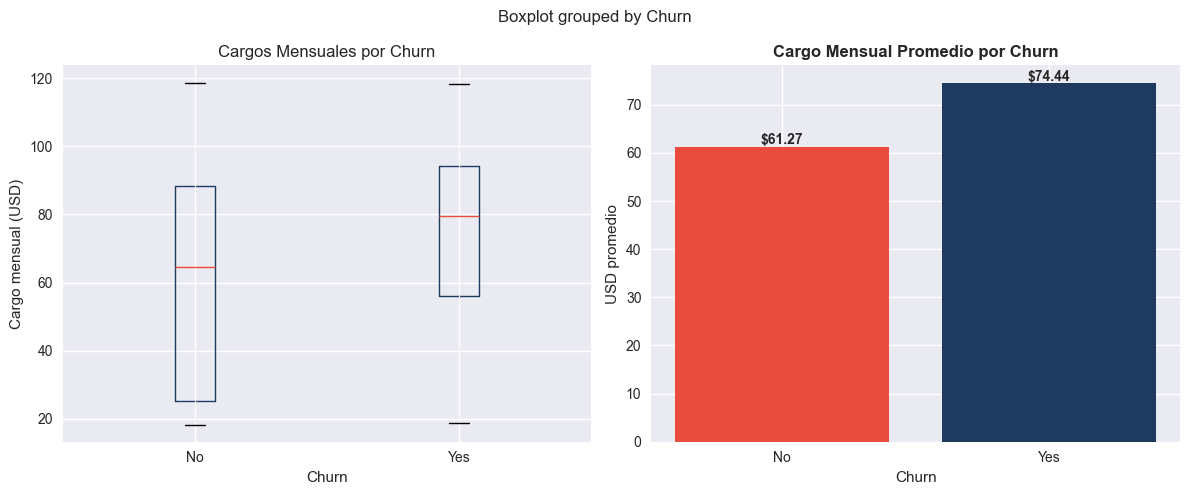


Cargo mensual promedio:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [6]:
# Churn según el cargo mensual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de cargos mensuales por churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           boxprops=dict(color='#1F3A5F'),
           medianprops=dict(color='#E74C3C'))
axes[0].set_title('Cargos Mensuales por Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cargo mensual (USD)')
plt.sca(axes[0])
plt.title('Cargos Mensuales por Churn')

# Promedio de cargos por churn
charges_avg = df.groupby('Churn')['MonthlyCharges'].mean()
axes[1].bar(charges_avg.index, charges_avg.values,
            color=['#E74C3C', '#1F3A5F'])
axes[1].set_title('Cargo Mensual Promedio por Churn', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('USD promedio')
for i, v in enumerate(charges_avg.values):
    axes[1].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../imagenes/04_churn_por_cargos.png', dpi=150)
plt.show()

print("\nCargo mensual promedio:")
print(charges_avg.round(2))

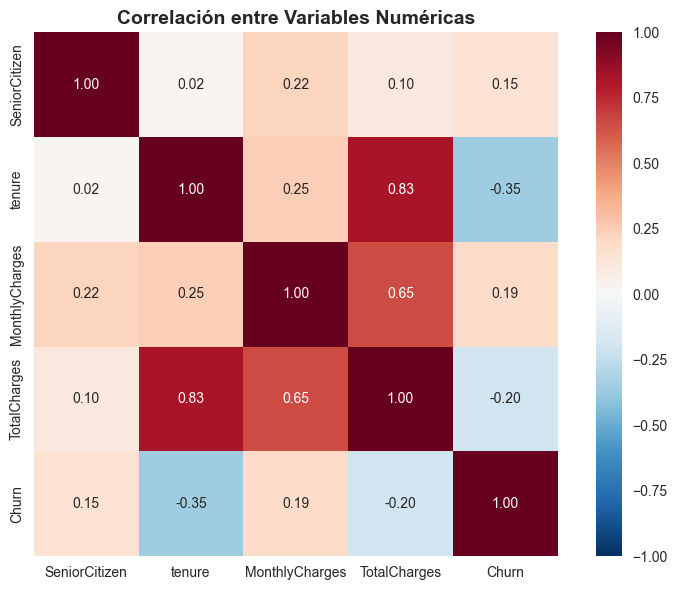

In [7]:
# Preparar datos para correlación
df_encoded = df.copy()
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

# Seleccionar columnas numéricas
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 
                'TotalCharges', 'Churn']

# TotalCharges viene como texto, hay que convertirla
df_encoded['TotalCharges'] = pd.to_numeric(
    df_encoded['TotalCharges'], errors='coerce')

# Calcular correlaciones
corr_matrix = df_encoded[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True)
plt.title('Correlación entre Variables Numéricas', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../imagenes/05_heatmap_correlaciones.png', dpi=150)
plt.show()

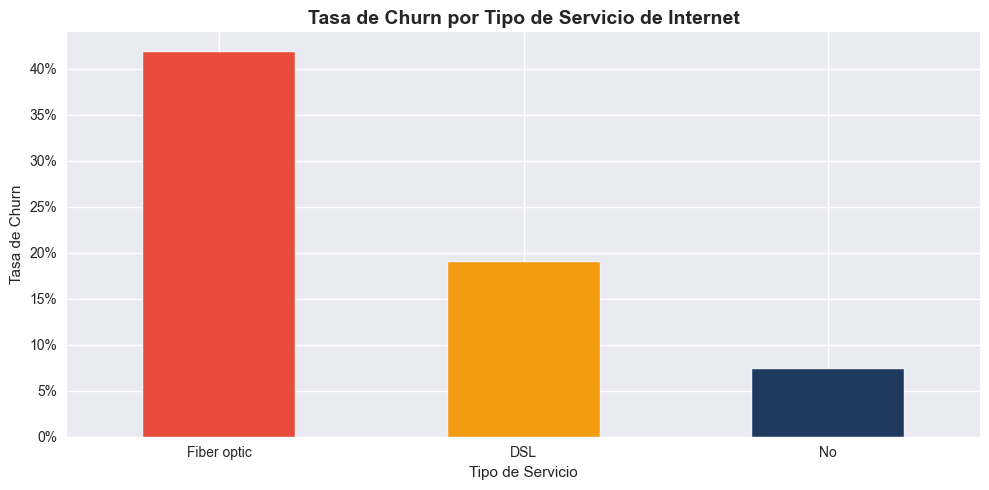


Tasa de churn por servicio de internet:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Yes, dtype: float64


In [8]:
# Churn por tipo de servicio de internet
plt.figure(figsize=(10, 5))
internet_churn = df.groupby('InternetService')['Churn'].value_counts(
    normalize=True).unstack()
internet_churn['Yes'].sort_values(ascending=False).plot(
    kind='bar', color=['#E74C3C', '#F39C12', '#1F3A5F'], edgecolor='white')
plt.title('Tasa de Churn por Tipo de Servicio de Internet',
          fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Servicio')
plt.ylabel('Tasa de Churn')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig('../imagenes/06_churn_por_internet.png', dpi=150)
plt.show()

print("\nTasa de churn por servicio de internet:")
print((internet_churn['Yes'] * 100).round(1))